In [1]:
import pandas as pd

In [3]:
df = pd.read_excel(r"C:\Users\User\Documents\SQL\Credit Risk Analysis Project\Data\final_credit_risk_dataset.xlsx")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   loan_duration_months     1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   loan_amount              1000 non-null   int64 
 5   status_savings           1000 non-null   object
 6   years_employment         1000 non-null   object
 7   payment_to_income_ratio  1000 non-null   int64 
 8   status_and_sex           1000 non-null   object
 9   secondary_obligor        1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  collateral               1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [10]:
features = [
    'age',
    'loan_amount',
    'loan_duration_months',
    'payment_to_income_ratio',
    'number_of_credits',
    'credit_history',
    'status_savings',
    'years_employment',
    'housing',
    'purpose'
]

In [11]:
y = df['target_binary']

In [12]:
X = pd.get_dummies(
    df[features],
    drop_first=True
)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=5000
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.745

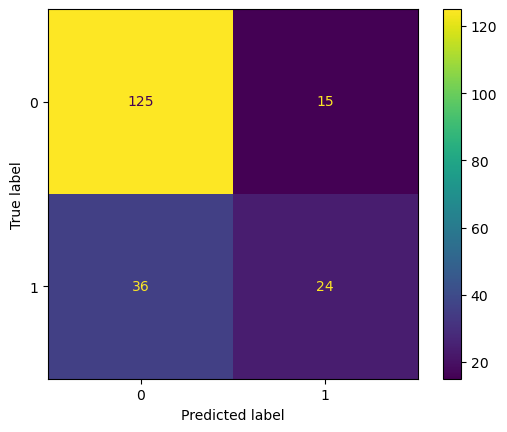

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test
)

In [23]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.78      0.89      0.83       140
           1       0.62      0.40      0.48        60

    accuracy                           0.74       200
   macro avg       0.70      0.65      0.66       200
weighted avg       0.73      0.74      0.73       200



In [24]:
from sklearn.metrics import roc_auc_score

probabilities = model.predict_proba(X_test)[:,1]

roc_auc_score(
    y_test,
    probabilities
)

0.753095238095238

In [25]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    'Coefficient',
    ascending=False
)

importance.head(15)

,Feature,Coefficient
22,purpose_education,1.031397
19,purpose_car (new),0.607079
14,years_employment_< 1 year,0.559725
16,years_employment_unemployed,0.556386
10,status_savings_< 100 DM,0.431604
18,housing_rent,0.358763
26,purpose_repairs,0.357427
3,payment_to_income_ratio,0.286947
23,purpose_furniture/equipment,0.262751
8,credit_history_no credits taken/ all credits p...,0.184761


In [ ]:
## Purpose, savings status, and employment duration emerged as the strongest predictors of credit risk. 
## Customers with unstable employment and weaker savings profiles exhibited significantly higher probabilities 
## of being classified as bad credit risks.